In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

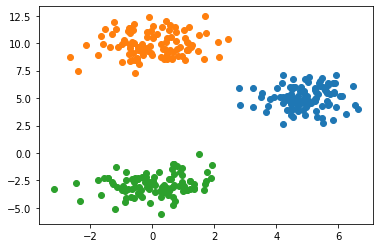

In [68]:
# toy example: 3 classes (1,2,3), 300 points in R^2
X = np.zeros((2,300))
y = np.zeros(300)

#class 1 points:
X[:,0:100] = np.random.randn(2,100) + np.array([[5],[5]])
y[0:100] = 1

#class 2 points:
X[:,100:200] = np.random.randn(2,100) + np.array([[0],[10]])
y[100:200] = 2

#class 3 points:

X[:,200:300] = np.random.randn(2,100) + np.array([[0],[-3]])
y[200:300] = 3

# plot data
plt.scatter(X[0,y==1], X[1, y==1])
plt.scatter(X[0,y==2], X[1, y==2])
plt.scatter(X[0,y==3], X[1, y==3])

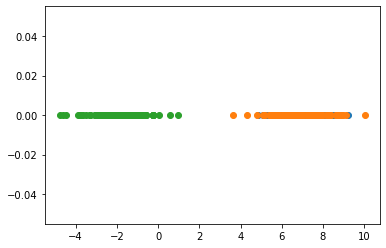

In [69]:
# example of a 'bad' projection
v = np.array([[1],[1]])
v=v/np.linalg.norm(v)

# projections
p = v.T.dot(X)
p = p.flatten()

# plot projected data

plt.scatter(p[y==1],np.zeros(100))

plt.scatter(p[y==2],np.zeros(100))

plt.scatter(p[y==3],np.zeros(100))

In [81]:
M = np.mean(X,axis=1, keepdims=True)
M1 = np.mean(X[:,y==1], axis=1, keepdims=True)
M2 = np.mean(X[:,y==2], axis=1, keepdims=True)
M3 = np.mean(X[:,y==3], axis=1, keepdims=True)

In [82]:
#matrix SB
SB = (M1-M).dot((M1-M).T)+(M2-M).dot((M2-M).T)+(M3-M).dot((M3-M).T)

In [83]:
#class sizes
n1 = np.sum(y==1)
n2 = np.sum(y==2)
n3 = np.sum(y==3)

In [84]:
# matrix SW
S1 = (X[:,y==1]-M1).dot( (X[:,y==1]-M1).T)
S2 = (X[:,y==2]-M2).dot((X[:,y==2]-M2).T)
S3 = (X[:,y==3]-M3).dot((X[:,y==3]-M3).T)

SW = S1/(n1-1)+S2/(n2-1)+S3/(n3-1)

In [85]:
SW

array([[2.60777886, 0.32867584],
       [0.32867584, 3.13583755]])

In [86]:
# solve the optimization problem
D,Q = eigh(SW)
inv_sqrt_SW = (Q.T*np.sqrt(1/D)).dot(Q)
D,Q = eigh(SB)
Q = inv_sqrt_SW.dot(Q)
# eigenvector with largest eigenvalue
v= Q[:,1]

In [87]:
v = v/np.linalg.norm(v,axis=0)

p = v.T.dot(X)
p = p.flatten()
#oops


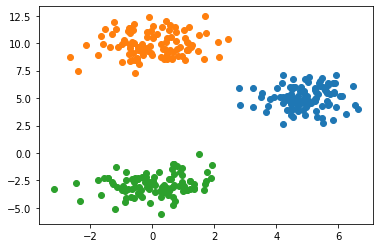

In [88]:
# plot data
plt.scatter(X[0,y==1], X[1, y==1])
plt.scatter(X[0,y==2], X[1, y==2])
plt.scatter(X[0,y==3], X[1, y==3])

LDA function

In [49]:
def lda(X,y,new_dim):
    
    # data points dimension, number of points
    original_dim, n = X.shape
    
    # data points mean
    M = np.mean(X,axis=1,keepdims=True)
    
    # classes
    classes = np.unique(y)
    n_classes = len(classes)
    
    # matrices SW and SB
    SW = np.zeros((original_dim, original_dim))
    SB = np.zeros((original_dim, original_dim))
    for i in range(n_classes):
        ni = np.sum(y==classes[i])
        Mi = np.mean(X[:,y==classes[i]], axis=1, keepdims=True)
        SB += (Mi-M).dot((Mi-M).T)
        SW += (X[:,y==classes[i]].dot((X[:,y==classes[i]]).T))/(ni-1)
        
    # solve the optimization problem
    D,Q = eigh(SW)
    inv_sqrt_SW = (Q.T*np.sqrt(1/D)).dot(Q)
    D,Q = eigh(SB)
    Q = inv_sqrt_SW.dot(Q)
    # eigenvector(s) with largest eigenvalue(s)
    # new_dim many
    v = Q[:,original_dim-new_dim:]
    #normalize columns
    v = v/np.linalg.norm(v,axis=0)
    return v

In [50]:
v = lda(X,y,new_dim=2)

Iris Flowers Example

In [52]:
import pandas as pd
iris = pd.read_csv('iris.csv')
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [60]:
y = iris['species'].to_numpy()

In [55]:
X = iris[['sepal_length','sepal_width','petal_length','petal_width']].to_numpy().T

In [57]:
v = lda(X, y, new_dim=2)

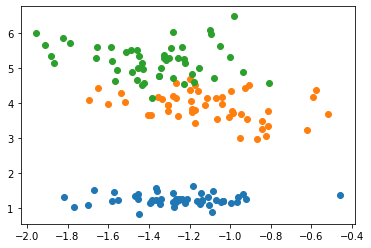

In [59]:
P = (v.T).dot(X)

# plot projected data
plt.scatter(P[0,y=='Iris-setosa'],P[1,y=='Iris-setosa'])
plt.scatter(P[0,y=='Iris-versicolor'],P[1,y=='Iris-versicolor'])
plt.scatter(P[0,y=='Iris-virginica'],P[1,y=='Iris-virginica'])